## **Environment Setup & Data Loading**

In [1]:
import pandas as pd
import numpy as np
import sys
import os
import statsmodels.api as sm
import importlib

In [2]:
sys.path.append(os.path.abspath("../"))

In [73]:
import src.scorecard_utils
import src.metrics

importlib.reload(src.scorecard_utils)
importlib.reload(src.metrics)

from src.scorecard_utils import fit_logistic_regression, iterative_p_value_elimination, check_beta_signs, generate_scorecard, calculate_scaling_params, calculate_customer_scores
from src.metrics import calculate_gini, calculate_ks

In [4]:
TRAIN_DATA_PATH = '../data/processed/train_woe_final_96.csv'
TEST_DATA_PATH = '../data/processed/test_woe_final_96.csv'

train_woe = pd.read_csv(TRAIN_DATA_PATH)
test_woe = pd.read_csv(TEST_DATA_PATH)

X_train = train_woe.drop(columns=['TARGET'])
y_train = train_woe['TARGET']

X_test = test_woe.drop(columns=['TARGET'])
y_test = test_woe['TARGET']

print(f"X_train shape: {X_train.shape} | y_train mean (Bad Rate): {y_train.mean():.4%}")
print(f"X_test shape: {X_test.shape} | y_test mean (Bad Rate): {y_test.mean():.4%}")

X_train shape: (32599, 96) | y_train mean (Bad Rate): 8.0739%
X_test shape: (92254, 96) | y_test mean (Bad Rate): 8.0734%


## **Initial Statistical Modeling (The Full Model)**

In [5]:
# Train the initial Logistic Regression model with all 96 features
full_model = fit_logistic_regression(X_train, y_train)

Optimization terminated successfully.
         Current function value: 0.244714
         Iterations 7


In [6]:
# This summary provides P-values, Coefficients (Beta), and Model Fit statistics
print(full_model.summary())

                           Logit Regression Results                           
Dep. Variable:                 TARGET   No. Observations:                32599
Model:                          Logit   Df Residuals:                    32502
Method:                           MLE   Df Model:                           96
Date:                Sat, 21 Feb 2026   Pseudo R-squ.:                  0.1278
Time:                        18:33:23   Log-Likelihood:                -7977.4
converged:                       True   LL-Null:                       -9146.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                           -2.5856      0.044    -58.351      0.000      -2.672      -2.499
EXT_SOURCE_2                 

In [7]:
# Calculate initial probabilities for the training set
y_prob_train_full = full_model.predict(sm.add_constant(X_train))

# Initial Performance Metrics
baseline_gini = calculate_gini(y_train, y_prob_train_full)
baseline_ks = calculate_ks(y_train, y_prob_train_full)

print("-" * 30)
print(f"Baseline Gini (Train): {baseline_gini:.4f}")
print(f"Baseline KS (Train)  : {baseline_ks:.4f}")

------------------------------
Baseline Gini (Train): 0.5235
Baseline KS (Train)  : 0.3878


In [8]:
stats_df = pd.DataFrame({
    'coef': full_model.params,
    'std_err': full_model.bse,
    'z_score': full_model.tvalues,
    'p_value': full_model.pvalues,
    'ci_lower': full_model.conf_int()[0],
    'ci_upper': full_model.conf_int()[1]
})

stats_df = stats_df.drop('const')

In [18]:
# 1. P-Value Clustering (Significance)
sig_count = (stats_df['p_value'] < 0.05).sum()
insig_count = (stats_df['p_value'] >= 0.05).sum()
print("P-VALUE CLUSTERING:")
print(f"Significant Features (P < 0.05): {sig_count}")
print(f"Insignificant Features (P >= 0.05): {insig_count}")

P-VALUE CLUSTERING:
Significant Features (P < 0.05): 31
Insignificant Features (P >= 0.05): 65


In [19]:
# 2. Coefficient Direction (Business Logic)
pos_coef = (stats_df['coef'] > 0).sum()
neg_coef = (stats_df['coef'] < 0).sum()
print("COEFFICIENT DIRECTION:")
print(f"Positive Coefficients (+): {pos_coef}")
print(f"Negative Coefficients (-): {neg_coef}")

COEFFICIENT DIRECTION:
Positive Coefficients (+): 20
Negative Coefficients (-): 76


In [20]:
# 3. Standard Error Spread (Model Confidence)
print("STANDARD ERROR SPREAD")
print(f"Min Error: {stats_df['std_err'].min():.4f} (Most reliable feature)")
print(f"Max Error: {stats_df['std_err'].max():.4f} (Least reliable feature)")
print(f"Mean Error: {stats_df['std_err'].mean():.4f}")

STANDARD ERROR SPREAD
Min Error: 0.0414 (Most reliable feature)
Max Error: 0.7954 (Least reliable feature)
Mean Error: 0.2627


In [21]:
# 4. Confidence Interval Check
crosses_zero = ((stats_df['ci_lower'] < 0) & (stats_df['ci_upper'] > 0)).sum()
print("CONFIDENCE INTERVAL:")
print(f"Features crossing zero (Potentially useless): {crosses_zero}")

CONFIDENCE INTERVAL:
Features crossing zero (Potentially useless): 65


In [17]:
print("\n--- TOP 30 MOST RELIABLE FEATURES ---")
top_reliable = stats_df[stats_df['p_value'] < 0.05].sort_values(by='std_err').head(30)
print(top_reliable[['coef', 'std_err', 'p_value']])


--- TOP 30 MOST RELIABLE FEATURES ---
                                      coef   std_err       p_value
EXT_SOURCE_2                     -0.780326  0.041432  3.982206e-79
ORGANIZATION_TYPE                -0.725618  0.085276  1.754243e-17
PREV_LTV_RATIO_MEAN              -0.496029  0.089190  2.674558e-08
DAYS_BIRTH                       -0.295217  0.093300  1.555202e-03
PREV_INS_AMT_PAYMENT_MIN_MEAN    -0.429038  0.095044  6.358935e-06
OCCUPATION_TYPE                  -0.340063  0.104350  1.118608e-03
BURO_DAYS_CREDIT_ENDDATE_MEAN    -0.290729  0.105767  5.981841e-03
DAYS_ID_PUBLISH                  -0.347932  0.108659  1.364558e-03
DAYS_LAST_PHONE_CHANGE           -0.304679  0.110832  5.977391e-03
FLAG_DOCUMENT_3                  -0.697303  0.116977  2.506218e-09
DAYS_REGISTRATION                -0.523674  0.124826  2.725954e-05
CODE_GENDER                      -0.885349  0.125003  1.414357e-12
NAME_INCOME_TYPE                  0.321059  0.126326  1.103764e-02
BURO_DAYS_CREDIT_MIN   

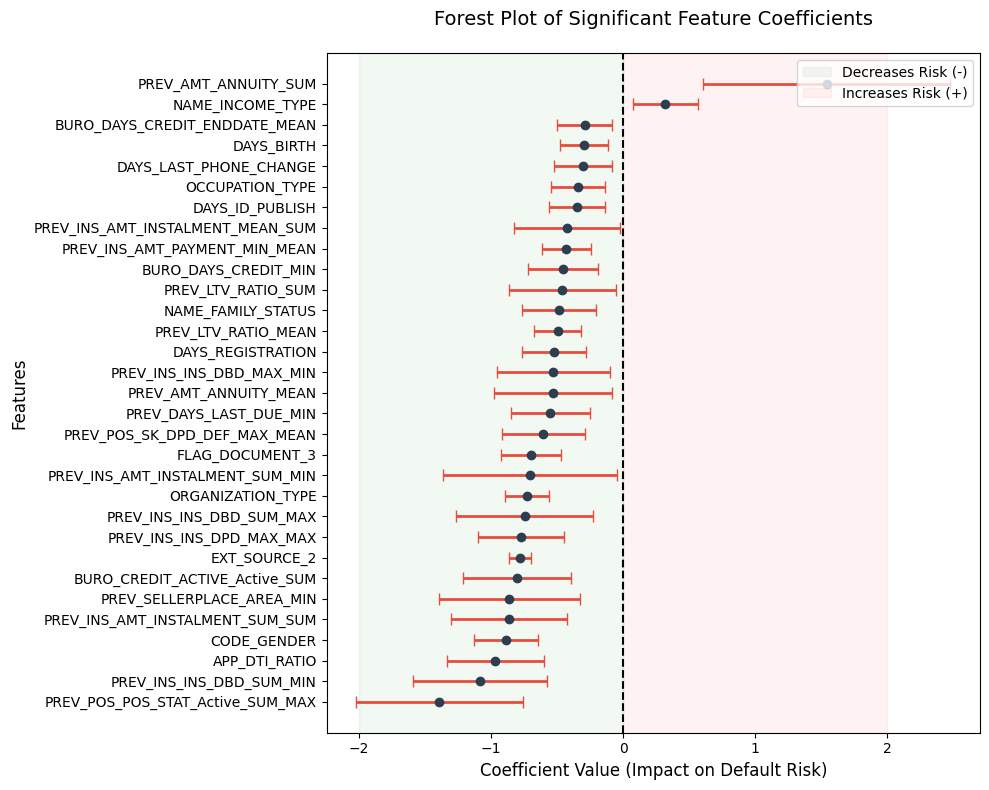

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sig_features = stats_df[stats_df['p_value'] < 0.05].sort_values(by='coef')

plt.figure(figsize=(10, 8))

plt.errorbar(x=sig_features['coef'], 
             y=sig_features.index, 
             xerr=sig_features['std_err'] * 1.96, # 95% Confidence Interval
             fmt='o', 
             color='#2c3e50', 
             ecolor='#e74c3c', 
             elinewidth=2, 
             capsize=4)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.title('Forest Plot of Significant Feature Coefficients', fontsize=14, pad=20)
plt.xlabel('Coefficient Value (Impact on Default Risk)', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.axvspan(-2, 0, color='green', alpha=0.05, label='Decreases Risk (-)')
plt.axvspan(0, 2, color='red', alpha=0.05, label='Increases Risk (+)')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## **Statistical Pruning (P-Value Selection)**

In [24]:
print(f"Initial feature count: {X_train.shape[1]}")

final_features, pruned_model = iterative_p_value_elimination(X_train, y_train, threshold=0.05)

X_train_pruned = X_train[final_features]
X_test_pruned = X_test[final_features]

Initial feature count: 96
Iteration 1: Removed 'PREV_INS_AMT_INSTALMENT_MEAN_MIN' with P-Value: 0.9581
Iteration 2: Removed 'PREV_INS_AMT_PAYMENT_SUM_MAX' with P-Value: 0.9426
Iteration 3: Removed 'PREV_AMT_APPLICATION_SUM' with P-Value: 0.9410
Iteration 4: Removed 'REG_CITY_NOT_WORK_CITY' with P-Value: 0.8946
Iteration 5: Removed 'BURO_CREDIT_TYPE_Credit card_MEAN' with P-Value: 0.8797
Iteration 6: Removed 'REGION_POPULATION_RELATIVE' with P-Value: 0.8263
Iteration 7: Removed 'PREV_AMT_ANNUITY_MAX' with P-Value: 0.8265
Iteration 8: Removed 'PREV_POS_CNT_INSTALMENT_MAX_MIN' with P-Value: 0.8210
Iteration 9: Removed 'AMT_INCOME_TOTAL' with P-Value: 0.8144
Iteration 10: Removed 'PREV_POS_POS_STAT_Active_MEAN_MIN' with P-Value: 0.8061
Iteration 11: Removed 'PREV_AMT_APPLICATION_MEAN' with P-Value: 0.7587
Iteration 12: Removed 'PREV_INS_NUM_INSTALMENT_VERSION_NUNIQUE_MEAN' with P-Value: 0.7462
Iteration 13: Removed 'PREV_POS_CNT_INSTALMENT_LAST_MEAN' with P-Value: 0.7316
Iteration 14: Remo

In [25]:
print("\n" + "="*50)
print(pruned_model.summary())
print("="*50)


                           Logit Regression Results                           
Dep. Variable:                 TARGET   No. Observations:                32599
Model:                          Logit   Df Residuals:                    32557
Method:                           MLE   Df Model:                           41
Date:                Sat, 21 Feb 2026   Pseudo R-squ.:                  0.1243
Time:                        18:53:44   Log-Likelihood:                -8009.5
converged:                       True   LL-Null:                       -9146.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                     -2.5608      0.032    -81.280      0.000      -2.623      -2.499
EXT_SOURCE_2                              -0.7

In [26]:
y_prob_train_pruned = pruned_model.predict(sm.add_constant(X_train_pruned))

pruned_gini = calculate_gini(y_train, y_prob_train_pruned)
pruned_ks = calculate_ks(y_train, y_prob_train_pruned)

print(f"Features      : 96 -> {len(final_features)}")
print(f"Baseline Gini : {baseline_gini:.4f} -> Pruned Gini: {pruned_gini:.4f}")
print(f"Baseline KS   : {baseline_ks:.4f} -> Pruned KS  : {pruned_ks:.4f}")

Features      : 96 -> 41
Baseline Gini : 0.5235 -> Pruned Gini: 0.5163
Baseline KS   : 0.3878 -> Pruned KS  : 0.3865


In [27]:
stats_pruned = pd.DataFrame({
    'coef': pruned_model.params,
    'std_err': pruned_model.bse,
    'z_score': pruned_model.tvalues,
    'p_value': pruned_model.pvalues,
    'ci_lower': pruned_model.conf_int()[0],
    'ci_upper': pruned_model.conf_int()[1]
}).drop('const')

stats_pruned['odds_ratio'] = np.exp(stats_pruned['coef'])

In [28]:
# 1. P-Value Clustering (The purity check)
sig_count = (stats_pruned['p_value'] < 0.05).sum()
insig_count = (stats_pruned['p_value'] >= 0.05).sum()
print(f"P-VALUE CLUSTERING:")
print(f"Significant (P < 0.05): {sig_count} (Expected: All of them)")
print(f"Insignificant (P >= 0.05): {insig_count} (Expected: 0)")

P-VALUE CLUSTERING:
Significant (P < 0.05): 41 (Expected: All of them)
Insignificant (P >= 0.05): 0 (Expected: 0)


In [29]:
# 2. Coefficient Direction (Business Logic Preview)
pos_coef = (stats_pruned['coef'] > 0).sum()
neg_coef = (stats_pruned['coef'] < 0).sum()
print(f"COEFFICIENT DIRECTION:")
print(f"Positive (+) [Increases Risk]: {pos_coef}")
print(f"Negative (-) [Decreases Risk]: {neg_coef}")

COEFFICIENT DIRECTION:
Positive (+) [Increases Risk]: 2
Negative (-) [Decreases Risk]: 39


In [30]:
# 3. Standard Error Spread (Model Confidence Check)
print(f"STANDARD ERROR SPREAD:")
print(f"Min Error: {stats_pruned['std_err'].min():.4f}")
print(f"Max Error: {stats_pruned['std_err'].max():.4f}")
print(f"Mean Error: {stats_pruned['std_err'].mean():.4f}")

STANDARD ERROR SPREAD:
Min Error: 0.0408
Max Error: 0.3715
Mean Error: 0.1631


In [31]:
# 4. Confidence Interval
crosses_zero = ((stats_pruned['ci_lower'] < 0) & (stats_pruned['ci_upper'] > 0)).sum()
print(f"CONFIDENCE INTERVAL:")
print(f"Features crossing zero: {crosses_zero} (Expected: 0)")

CONFIDENCE INTERVAL:
Features crossing zero: 0 (Expected: 0)


In [32]:
print("\n--- TOP 30 MOST POWERFUL FEATURES---")
top_powerful = stats_pruned.copy()
top_powerful['abs_z'] = top_powerful['z_score'].abs()
print(top_powerful.sort_values(by='abs_z', ascending=False)[['coef', 'odds_ratio', 'p_value', 'z_score']].head(30))


--- TOP 30 MOST POWERFUL FEATURES---
                                            coef  odds_ratio       p_value  \
EXT_SOURCE_2                           -0.787234    0.455102  8.095320e-83   
BURO_CREDIT_ACTIVE_Active_SUM          -1.114955    0.327930  3.390674e-22   
ORGANIZATION_TYPE                      -0.733381    0.480282  5.682982e-18   
CODE_GENDER                            -0.881030    0.414356  6.944704e-13   
PREV_LTV_RATIO_MEAN                    -0.535573    0.585334  3.370063e-10   
FLAG_DOCUMENT_3                        -0.708114    0.492572  1.084076e-09   
PREV_POS_POS_STAT_Active_SUM_MAX       -1.505965    0.221803  4.398727e-08   
PREV_INS_INS_DPD_MAX_MAX               -0.816539    0.441959  5.632820e-08   
PREV_INS_AMT_PAYMENT_MIN_MEAN          -0.464781    0.628273  1.057934e-07   
APP_DTI_RATIO                          -0.970644    0.378839  1.574380e-07   
PREV_POS_CNT_INSTALMENT_FUTURE_MIN_MAX -0.975009    0.377189  1.224567e-06   
PREV_DAYS_LAST_DUE_MIN    

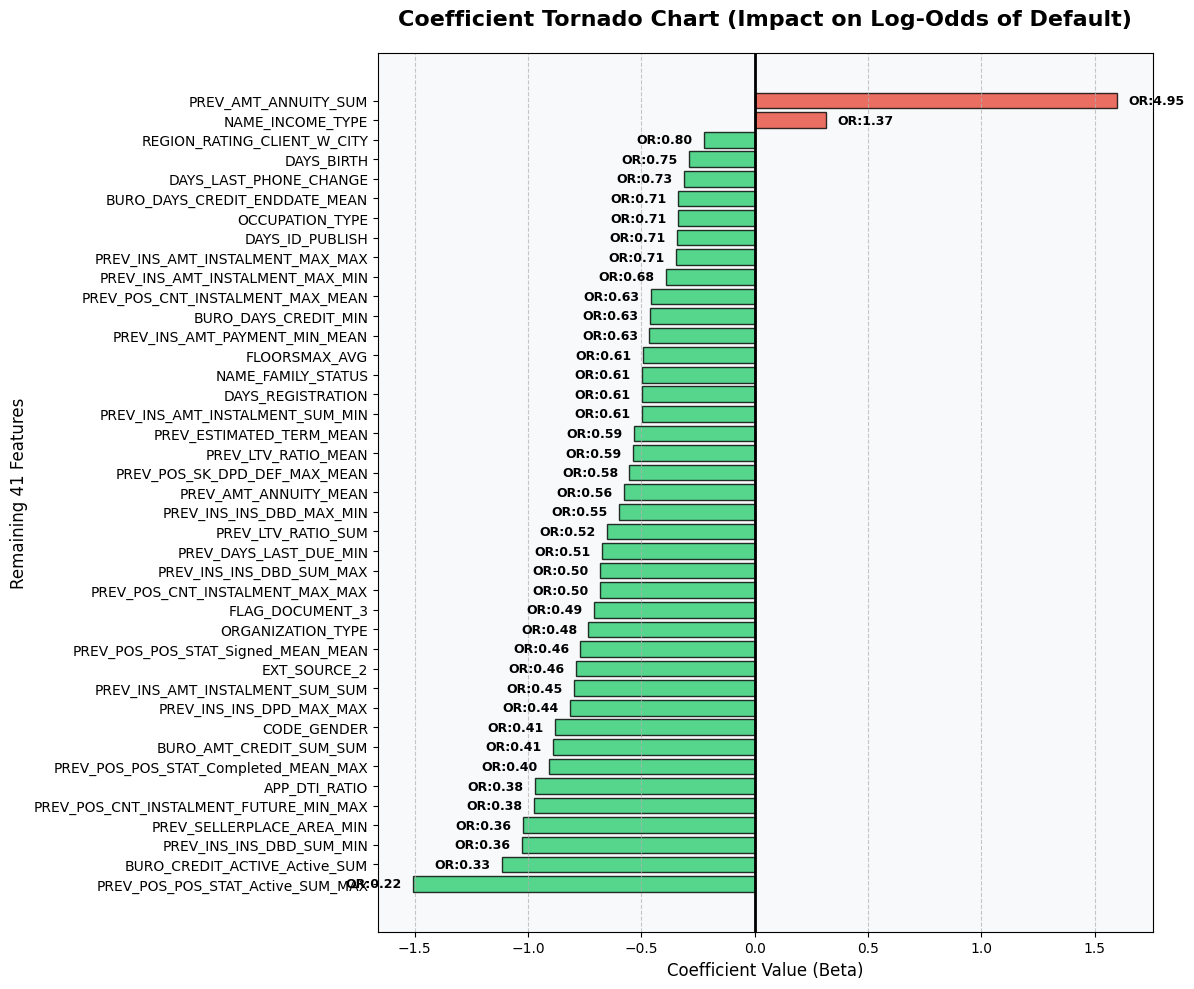

In [36]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = stats_pruned.sort_values(by='coef')

plt.figure(figsize=(12, 10))

# Color coding: Red for positive (Risk Increasing), Green for negative (Risk Decreasing)
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in plot_data['coef']]

bars = plt.barh(plot_data.index, plot_data['coef'], color=colors, edgecolor='black', alpha=0.8)
plt.axvline(x=0, color='black', linestyle='-', linewidth=2)

plt.title('Coefficient Tornado Chart (Impact on Log-Odds of Default)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Coefficient Value (Beta)', fontsize=12)
plt.ylabel('Remaining 41 Features', fontsize=12)

for i, bar in enumerate(bars):
    val = bar.get_width()
    or_val = plot_data['odds_ratio'].iloc[i]
    text_x = val + 0.05 if val > 0 else val - 0.05
    ha = 'left' if val > 0 else 'right'
    plt.text(text_x, bar.get_y() + bar.get_height()/2, f"OR:{or_val:.2f}", 
             va='center', ha=ha, fontsize=9, color='black', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

## **Logical Consistency & Sign Check**

In [40]:
violating_features = check_beta_signs(pruned_model, expected_sign='negative')

print(f"{len(violating_features)} features violating business logic:")
for feat in violating_features:
    coef_val = pruned_model.params[feat]
    print(f" - {feat} (Coefficient: {coef_val:.4f})")

2 features violating business logic:
 - NAME_INCOME_TYPE (Coefficient: 0.3149)
 - PREV_AMT_ANNUITY_SUM (Coefficient: 1.5990)


In [41]:
final_business_features = [f for f in final_features if f not in violating_features]

print(f"Features remaining: {len(final_features)} -> {len(final_business_features)}")

X_train_logical = X_train_pruned[final_business_features]
X_test_logical = X_test_pruned[final_business_features]

Features remaining: 41 -> 39


In [42]:
final_logical_model = fit_logistic_regression(X_train_logical, y_train)

y_prob_train_logical = final_logical_model.predict(sm.add_constant(X_train_logical))

logical_gini = calculate_gini(y_train, y_prob_train_logical)
logical_ks = calculate_ks(y_train, y_prob_train_logical) 

Optimization terminated successfully.
         Current function value: 0.246083
         Iterations 7


In [43]:
print("\n" + "="*50)
print(final_logical_model.summary())
print("="*50)


                           Logit Regression Results                           
Dep. Variable:                 TARGET   No. Observations:                32599
Model:                          Logit   Df Residuals:                    32559
Method:                           MLE   Df Model:                           39
Date:                Sat, 21 Feb 2026   Pseudo R-squ.:                  0.1229
Time:                        19:11:20   Log-Likelihood:                -8022.1
converged:                       True   LL-Null:                       -9146.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                     -2.5785      0.031    -82.516      0.000      -2.640      -2.517
EXT_SOURCE_2                              -0.7

In [44]:
print(f"Features      : 41 -> {len(final_business_features)}")
print(f"Pruned Gini   : {pruned_gini:.4f} -> Logical Gini: {logical_gini:.4f}")
print(f"Pruned KS     : {pruned_ks:.4f} -> Logical KS: {logical_ks:.4f}")

Features      : 41 -> 39
Pruned Gini   : 0.5163 -> Logical Gini: 0.5139
Pruned KS     : 0.3865 -> Logical KS: 0.3796


In [45]:
stats_logical = pd.DataFrame({
    'coef': final_logical_model.params,
    'std_err': final_logical_model.bse,
    'z_score': final_logical_model.tvalues,
    'p_value': final_logical_model.pvalues,
    'ci_lower': final_logical_model.conf_int()[0],
    'ci_upper': final_logical_model.conf_int()[1]
}).drop('const')

stats_logical['odds_ratio'] = np.exp(stats_logical['coef'])

In [47]:
# 1. P-Value Clustering (The purity check)
sig_count = (stats_logical['p_value'] < 0.05).sum()
insig_count = (stats_logical['p_value'] >= 0.05).sum()
print(f"P-VALUE CLUSTERING:")
print(f"Significant (P < 0.05): {sig_count} (Expected: All 39)")
print(f"Insignificant (P >= 0.05): {insig_count} (Expected: 0)")

P-VALUE CLUSTERING:
Significant (P < 0.05): 39 (Expected: All 39)
Insignificant (P >= 0.05): 0 (Expected: 0)


In [48]:
# 2. Coefficient Direction (Business Logic Verification)
pos_coef = (stats_logical['coef'] > 0).sum()
neg_coef = (stats_logical['coef'] < 0).sum()
print(f"COEFFICIENT DIRECTION:")
print(f"Positive (+) [Increases Risk]: {pos_coef} (Expected: 0)")
print(f"Negative (-) [Decreases Risk]: {neg_coef} (Expected: All 39)")

COEFFICIENT DIRECTION:
Positive (+) [Increases Risk]: 0 (Expected: 0)
Negative (-) [Decreases Risk]: 39 (Expected: All 39)


In [49]:
# 3. Standard Error Spread (Model Confidence Check)
print(f"STANDARD ERROR SPREAD:")
print(f"Min Error: {stats_logical['std_err'].min():.4f}")
print(f"Max Error: {stats_logical['std_err'].max():.4f}")
print(f"Mean Error: {stats_logical['std_err'].mean():.4f}")

STANDARD ERROR SPREAD:
Min Error: 0.0408
Max Error: 0.3082
Mean Error: 0.1572


In [50]:
# 4. Confidence Interval
crosses_zero = ((stats_logical['ci_lower'] < 0) & (stats_logical['ci_upper'] > 0)).sum()
print(f"CONFIDENCE INTERVAL:")
print(f"Features crossing zero: {crosses_zero} (Expected: 0)")

CONFIDENCE INTERVAL:
Features crossing zero: 0 (Expected: 0)


In [51]:
# 5. Top 30 Most Powerful Features (By Absolute Z-Score)
print("\n--- TOP 30 MOST POWERFUL FEATURES ---")
top_powerful = stats_logical.copy()
top_powerful['abs_z'] = top_powerful['z_score'].abs()
print(top_powerful.sort_values(by='abs_z', ascending=False)[['coef', 'odds_ratio', 'p_value', 'z_score']].head(30))


--- TOP 30 MOST POWERFUL FEATURES ---
                                            coef  odds_ratio       p_value  \
EXT_SOURCE_2                           -0.793057    0.452459  3.671772e-84   
BURO_CREDIT_ACTIVE_Active_SUM          -1.132358    0.322273  7.241776e-23   
ORGANIZATION_TYPE                      -0.642579    0.525934  5.530640e-17   
CODE_GENDER                            -0.857673    0.424148  2.337060e-12   
PREV_LTV_RATIO_MEAN                    -0.549883    0.577017  9.215306e-11   
PREV_INS_INS_DPD_MAX_MAX               -0.888367    0.411327  2.670517e-09   
FLAG_DOCUMENT_3                        -0.670500    0.511453  5.557306e-09   
PREV_POS_POS_STAT_Active_SUM_MAX       -1.508411    0.221261  4.046889e-08   
APP_DTI_RATIO                          -0.959331    0.383149  2.155690e-07   
PREV_SELLERPLACE_AREA_MIN              -1.253772    0.285426  2.920437e-07   
PREV_INS_AMT_PAYMENT_MIN_MEAN          -0.403438    0.668019  3.036904e-06   
BURO_DAYS_CREDIT_MIN     

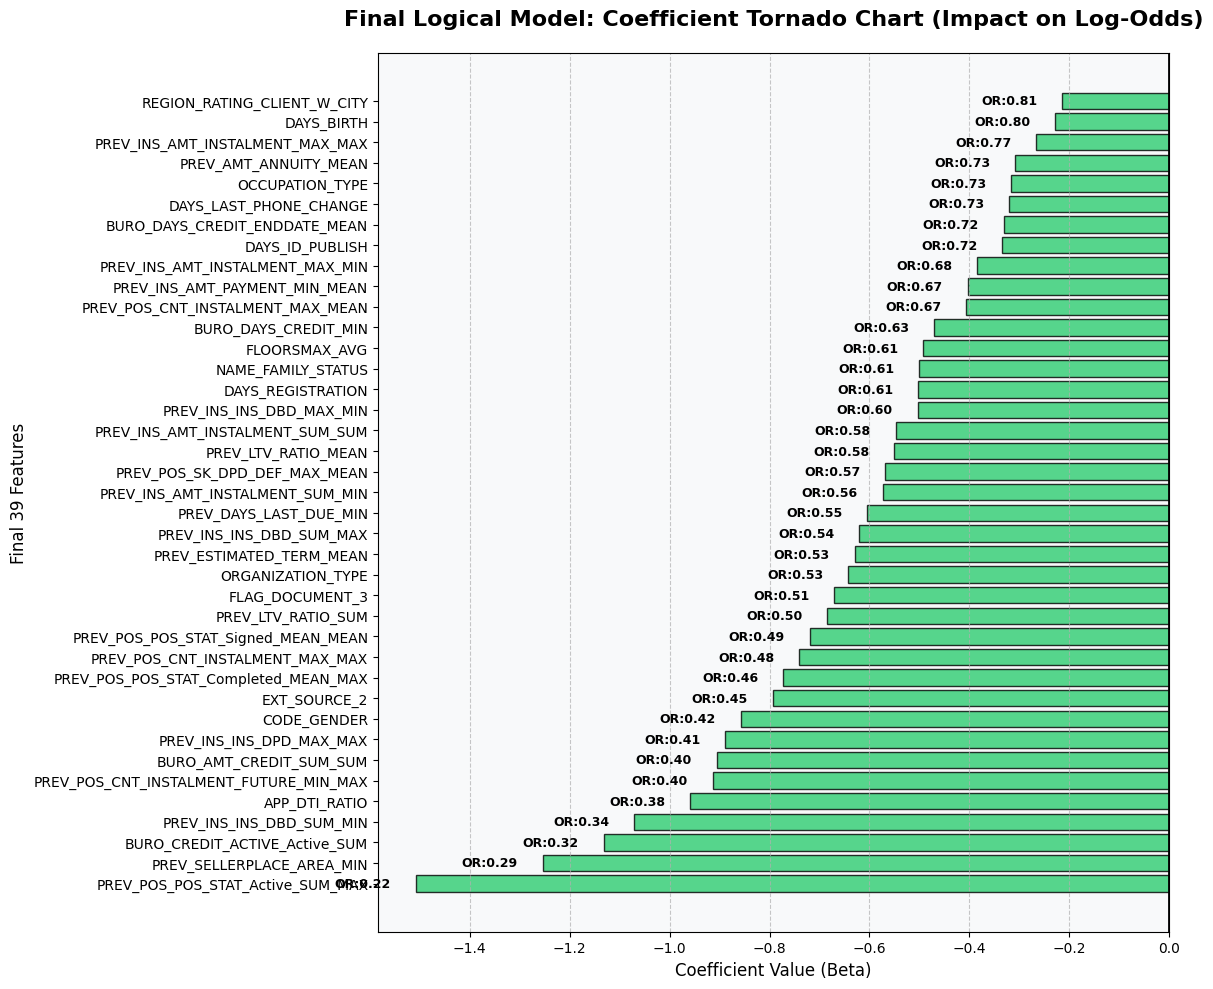

In [53]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = stats_logical.sort_values(by='coef')

plt.figure(figsize=(12, 10))

# Color coding: Red for positive (Risk Increasing), Green for negative (Risk Decreasing)
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in plot_data['coef']]

bars = plt.barh(plot_data.index, plot_data['coef'], color=colors, edgecolor='black', alpha=0.8)
plt.axvline(x=0, color='black', linestyle='-', linewidth=2)

plt.title('Final Logical Model: Coefficient Tornado Chart (Impact on Log-Odds)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Coefficient Value (Beta)', fontsize=12)
plt.ylabel('Final 39 Features', fontsize=12)

for i, bar in enumerate(bars):
    val = bar.get_width()
    or_val = plot_data['odds_ratio'].iloc[i]
    text_x = val + 0.05 if val > 0 else val - 0.05
    ha = 'left' if val > 0 else 'right'
    plt.text(text_x, bar.get_y() + bar.get_height()/2, f"OR:{or_val:.2f}", 
             va='center', ha=ha, fontsize=9, color='black', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

In [55]:
final_feature_columns = X_train_logical.columns.tolist()

X_test_logical = X_test[final_feature_columns]

print(f"Train Set Shape: {X_train_logical.shape}")
print(f"Test Set Shape : {X_test_logical.shape}")

if list(X_train_logical.columns) == list(X_test_logical.columns):
    print("Train and Test features are aligned")
else:
    print("Feature alignment failed")

Train Set Shape: (32599, 39)
Test Set Shape : (92254, 39)
Train and Test features are aligned


In [56]:
train_final_df = X_train_logical.copy()
train_final_df['TARGET'] = y_train

test_final_df = X_test_logical.copy()
test_final_df['TARGET'] = y_test

TRAIN_SAVE_PATH = '../data/processed/train_woe_logical_39.csv'
TEST_SAVE_PATH = '../data/processed/test_woe_logical_39.csv'

os.makedirs('../data/processed/', exist_ok=True)

train_final_df.to_csv(TRAIN_SAVE_PATH, index=False)
test_final_df.to_csv(TEST_SAVE_PATH, index=False)

## **Final Model Estimation & Performance Check**

In [62]:
y_prob_train = final_logical_model.predict(sm.add_constant(X_train_logical))
y_prob_test  = final_logical_model.predict(sm.add_constant(X_test_logical))

# Calculate Gini and KS for Train Set
final_gini_train = calculate_gini(y_train, y_prob_train)
final_ks_train   = calculate_ks(y_train, y_prob_train)

# Calculate Gini and KS for Test Set
final_gini_test = calculate_gini(y_test, y_prob_test)
final_ks_test   = calculate_ks(y_test, y_prob_test)

print(f"{'Metric':<15} | {'Train Set':<18} | {'Test Set':<18} | {'Difference':<10}")
print(f"{'Gini Score':<15} | {final_gini_train:.4f}             | {final_gini_test:.4f}             | {(final_gini_train - final_gini_test):.4f}")
print(f"{'KS Statistic':<15} | {final_ks_train:.4f}             | {final_ks_test:.4f}             | {(final_ks_train - final_ks_test):.4f}")

Metric          | Train Set          | Test Set           | Difference
Gini Score      | 0.5139             | 0.4551             | 0.0589
KS Statistic    | 0.3796             | 0.3363             | 0.0433


## **Scorecard Scaling (Log-Odds to Points)**

In [67]:
print("Parameters: PDO=20, Base Score=600, Base Odds=50:1\n")

intercept_points, scorecard_df = generate_scorecard(
    model_result=final_logical_model, 
    features=final_business_features, 
    pdo=20, 
    base_score=600, 
    base_odds=50
)

print(f"BASE INTERCEPT POINTS: {intercept_points}")

Parameters: PDO=20, Base Score=600, Base Odds=50:1

BASE INTERCEPT POINTS: 562


In [70]:
print("\n--- SCORECARD FEATURE POINTS---")
print(scorecard_df.head(39).to_string(index=False))


--- SCORECARD FEATURE POINTS---
                               Feature  Coefficient  Points
      PREV_POS_POS_STAT_Active_SUM_MAX    -1.508411    44.0
             PREV_SELLERPLACE_AREA_MIN    -1.253772    36.0
         BURO_CREDIT_ACTIVE_Active_SUM    -1.132358    33.0
              PREV_INS_INS_DBD_SUM_MIN    -1.070362    31.0
                         APP_DTI_RATIO    -0.959331    28.0
              PREV_INS_INS_DPD_MAX_MAX    -0.888367    26.0
               BURO_AMT_CREDIT_SUM_SUM    -0.906093    26.0
PREV_POS_CNT_INSTALMENT_FUTURE_MIN_MAX    -0.913477    26.0
                           CODE_GENDER    -0.857673    25.0
                          EXT_SOURCE_2    -0.793057    23.0
  PREV_POS_POS_STAT_Completed_MEAN_MAX    -0.773010    22.0
       PREV_POS_CNT_INSTALMENT_MAX_MAX    -0.740270    21.0
    PREV_POS_POS_STAT_Signed_MEAN_MEAN    -0.719508    21.0
                    PREV_LTV_RATIO_SUM    -0.684625    20.0
                     ORGANIZATION_TYPE    -0.642579    19.0
       

In [71]:
scorecard_export = scorecard_df.copy()

intercept_row = pd.DataFrame({
    'Feature': ['BASE_INTERCEPT_POINTS'],
    'Coefficient': [np.nan],
    'Points': [intercept_points]
})

scorecard_export = pd.concat([intercept_row, scorecard_export], ignore_index=True)

SCORECARD_SAVE_PATH = '../data/processed/scorecard_mapping_39.csv'

scorecard_export.to_csv(SCORECARD_SAVE_PATH, index=False)

print(scorecard_export.head())

                            Feature  Coefficient  Points
0             BASE_INTERCEPT_POINTS          NaN   562.0
1  PREV_POS_POS_STAT_Active_SUM_MAX    -1.508411    44.0
2         PREV_SELLERPLACE_AREA_MIN    -1.253772    36.0
3     BURO_CREDIT_ACTIVE_Active_SUM    -1.132358    33.0
4          PREV_INS_INS_DBD_SUM_MIN    -1.070362    31.0


In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

scores_train = calculate_customer_scores(X_train_logical, scorecard_df, intercept_points)
scores_test  = calculate_customer_scores(X_test_logical, scorecard_df, intercept_points)

X_train_logical_scored = X_train_logical.copy()
X_train_logical_scored['SCORE'] = scores_train

X_test_logical_scored = X_test_logical.copy()
X_test_logical_scored['SCORE'] = scores_test

print("SCORECARD SUMMARY STATISTICS")
print(f"Train Set - Min: {scores_train.min()}  | Max: {scores_train.max()}  | Mean: {scores_train.mean():.0f}")
print(f"Test Set  - Min: {scores_test.min()}  | Max: {scores_test.max()}  | Mean: {scores_test.mean():.0f}")

SCORECARD SUMMARY STATISTICS
Train Set - Min: 452  | Max: 676  | Mean: 570
Test Set  - Min: 440  | Max: 688  | Mean: 570


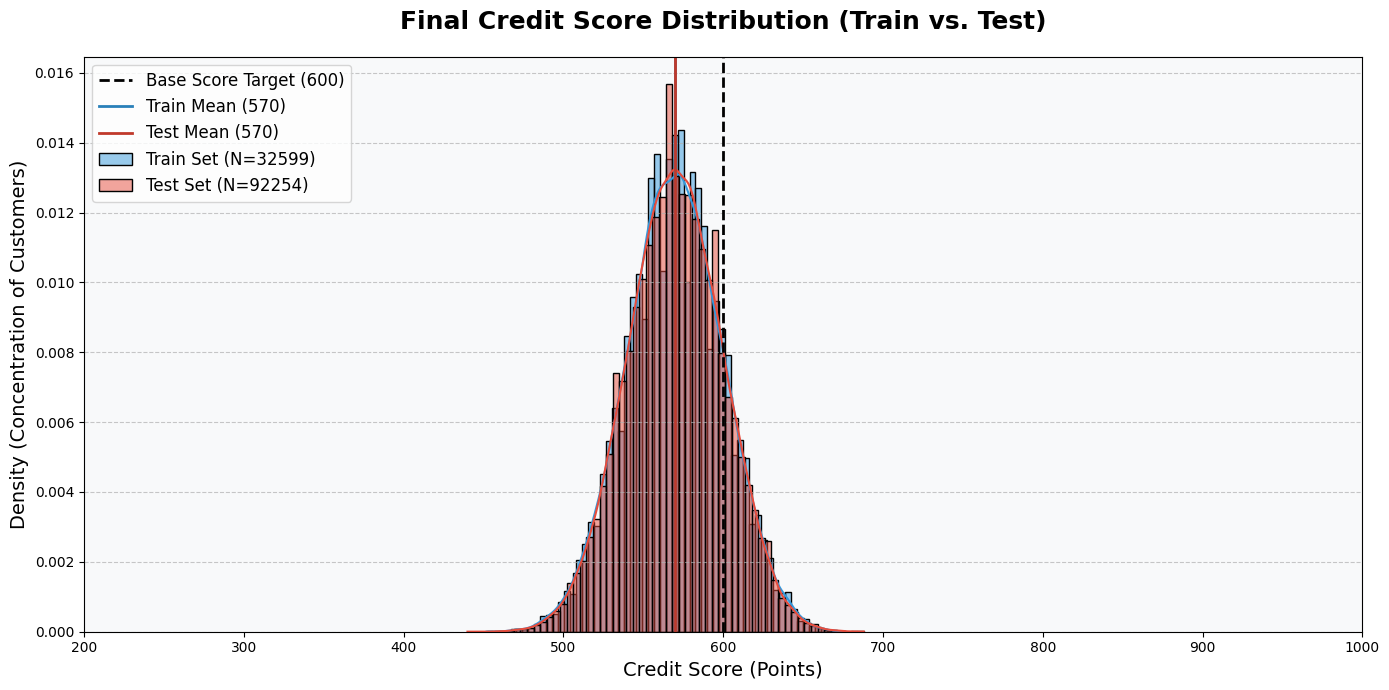

In [77]:
plt.figure(figsize=(14, 7))

sns.histplot(scores_train, color='#3498db', label=f'Train Set (N={len(scores_train)})', kde=True, stat='density', alpha=0.5, bins=60)
sns.histplot(scores_test, color='#e74c3c', label=f'Test Set (N={len(scores_test)})', kde=True, stat='density', alpha=0.5, bins=60)

plt.title('Final Credit Score Distribution (Train vs. Test)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Credit Score (Points)', fontsize=14)
plt.ylabel('Density (Concentration of Customers)', fontsize=14)

plt.axvline(x=600, color='black', linestyle='--', linewidth=2, label='Base Score Target (600)')

plt.axvline(x=scores_train.mean(), color='#2980b9', linestyle='-', linewidth=2, label=f'Train Mean ({scores_train.mean():.0f})')
plt.axvline(x=scores_test.mean(), color='#c0392b', linestyle='-', linewidth=2, label=f'Test Mean ({scores_test.mean():.0f})')

plt.xlim(200, 1000) 
plt.legend(fontsize=12, loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

## **Artefact Exporting**

In [80]:
import pickle

OUTPUT_MODEL_PATH = '../outputs/models/final_logit_model_39.pkl'
OUTPUT_SCORECARD_EXCEL = '../outputs/final_scorecard.xlsx'
OUTPUT_SCORECARD_CSV = '../outputs/scorecard_mapping_39.csv'
SCORED_TRAIN_PATH = '../data/outputs/train_scored_final.csv'
SCORED_TEST_PATH = '../data/outputs/test_scored_final.csv'

os.makedirs('../outputs/models/', exist_ok=True)
os.makedirs('../outputs/reports/', exist_ok=True)
os.makedirs('../data/outputs/', exist_ok=True)

scorecard_export = scorecard_df.copy()
intercept_row = pd.DataFrame({
    'Feature': ['BASE_INTERCEPT_POINTS'],
    'Coefficient': [np.nan],
    'Points': [intercept_points]
})
scorecard_export = pd.concat([intercept_row, scorecard_export], ignore_index=True)

with open(OUTPUT_MODEL_PATH, 'wb') as f:
    pickle.dump(final_logical_model, f)

scorecard_export.to_csv(OUTPUT_SCORECARD_CSV, index=False)
scorecard_export.to_excel(OUTPUT_SCORECARD_EXCEL, index=False, sheet_name='Scorecard_Recipe')

train_export = X_train_logical_scored.copy()
train_export['TARGET'] = y_train
train_export.to_csv(SCORED_TRAIN_PATH, index=False)

test_export = X_test_logical_scored.copy()
test_export['TARGET'] = y_test
test_export.to_csv(SCORED_TEST_PATH, index=False)

print(scorecard_export.head())

                            Feature  Coefficient  Points
0             BASE_INTERCEPT_POINTS          NaN   562.0
1  PREV_POS_POS_STAT_Active_SUM_MAX    -1.508411    44.0
2         PREV_SELLERPLACE_AREA_MIN    -1.253772    36.0
3     BURO_CREDIT_ACTIVE_Active_SUM    -1.132358    33.0
4          PREV_INS_INS_DBD_SUM_MIN    -1.070362    31.0
